In [1]:
# Cell 1: Upload dataset
from google.colab import files
uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv


In [2]:
# Cell 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

sns.set_theme(style="whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Cell 3: Load dataset
df = pd.read_csv("customer_churn.csv")

print("Dataset loaded successfully")
print(df.shape)
df.head()

Dataset loaded successfully
(500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
# Cell 4: Explore dataset
print("Columns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Columns:
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Data Types:
CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

Missing Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Duplicate Rows:
0


In [5]:
# Cell 5: Data cleaning
df = df.drop_duplicates()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Data cleaning completed")

Data cleaning completed


In [6]:
# Cell 6: Encode categorical columns
encoded_df = df.copy()

label_encoders = {}

for col in encoded_df.select_dtypes(include="object").columns:
    if col != "CustomerID":
        le = LabelEncoder()
        encoded_df[col] = le.fit_transform(encoded_df[col])
        label_encoders[col] = le

print("Categorical encoding completed")
encoded_df.head()

Categorical encoding completed


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,1,1,0,1,0
1,C00002,21,113,1753,0,2,1,1,0
2,C00003,27,31,1455,2,1,0,1,0
3,C00004,53,29,7150,0,2,0,1,0
4,C00005,16,185,1023,1,2,0,1,0


In [7]:
# Cell 7: Prepare clustering features
cluster_features = encoded_df.drop(["CustomerID", "Churn"], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

print("Features scaled successfully")

Features scaled successfully


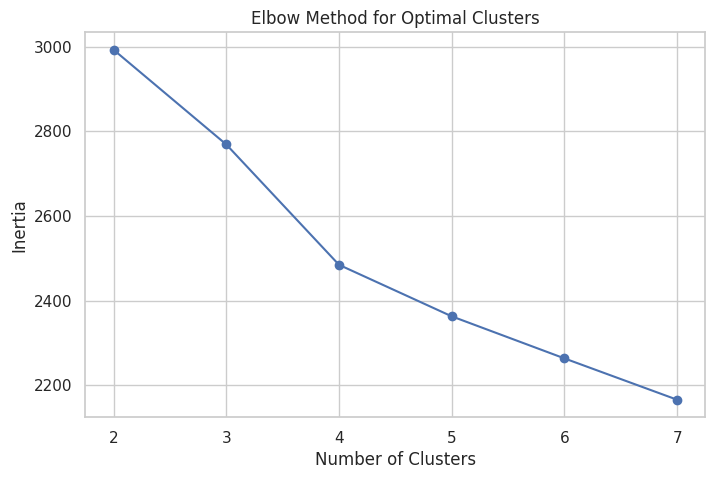

In [8]:
# Cell 8: Elbow method for K-Means
inertia_values = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia_values, marker="o")
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [9]:
# Cell 9: K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

encoded_df["KMeans_Segment"] = kmeans.fit_predict(scaled_features)

silhouette = silhouette_score(scaled_features, encoded_df["KMeans_Segment"])

print("K-Means clustering completed")
print("Silhouette Score:", silhouette)

K-Means clustering completed
Silhouette Score: 0.1182064934001234


In [10]:
# Cell 10: Agglomerative clustering
agg_model = AgglomerativeClustering(n_clusters=3)

encoded_df["Agglomerative_Segment"] = agg_model.fit_predict(scaled_features)

print("Agglomerative clustering completed")
encoded_df[["KMeans_Segment", "Agglomerative_Segment"]].head()

Agglomerative clustering completed


,KMeans_Segment,Agglomerative_Segment
0,1,0
1,1,2
2,2,0
3,1,0
4,1,0


In [11]:
# Cell 11: Segment profile analysis
segment_profile = encoded_df.groupby("KMeans_Segment").mean(numeric_only=True)

print("Customer Segment Profiles:")
segment_profile

Customer Segment Profiles:


,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Agglomerative_Segment
KMeans_Segment,,,,,,,,,
0,37.354582,119.083665,4201.083665,0.948207,1.027888,0.501992,0.0,0.111554,0.844622
1,35.992308,107.523077,4080.192308,0.323077,1.038462,0.253846,1.0,0.138462,0.384615
2,35.386555,108.823529,4487.764706,1.630252,0.932773,0.705882,1.0,0.058824,1.411765


In [12]:
# Cell 12: Name customer segments
segment_names = {
    0: "Budget Conscious Customers",
    1: "Premium Spenders",
    2: "At-Risk Customers"
}

encoded_df["Segment_Name"] = encoded_df["KMeans_Segment"].map(segment_names)

encoded_df[["CustomerID", "KMeans_Segment", "Segment_Name"]].head()

,CustomerID,KMeans_Segment,Segment_Name
0,C00001,1,Premium Spenders
1,C00002,1,Premium Spenders
2,C00003,2,At-Risk Customers
3,C00004,1,Premium Spenders
4,C00005,1,Premium Spenders


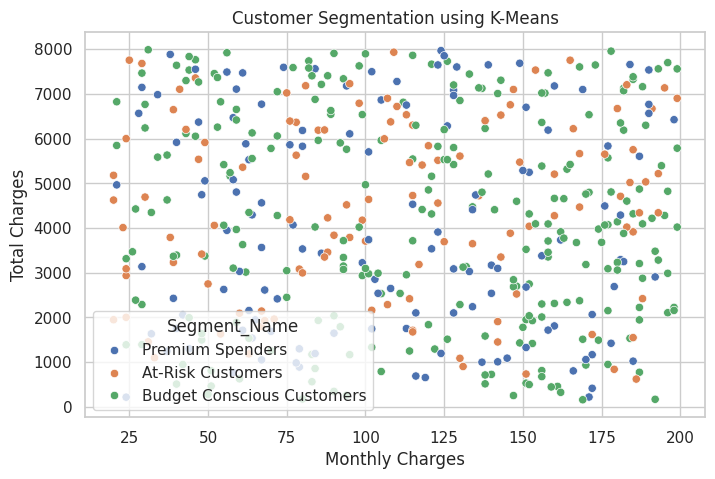

In [13]:
# Cell 13: Visualize customer segments
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=encoded_df["MonthlyCharges"],
    y=encoded_df["TotalCharges"],
    hue=encoded_df["Segment_Name"]
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

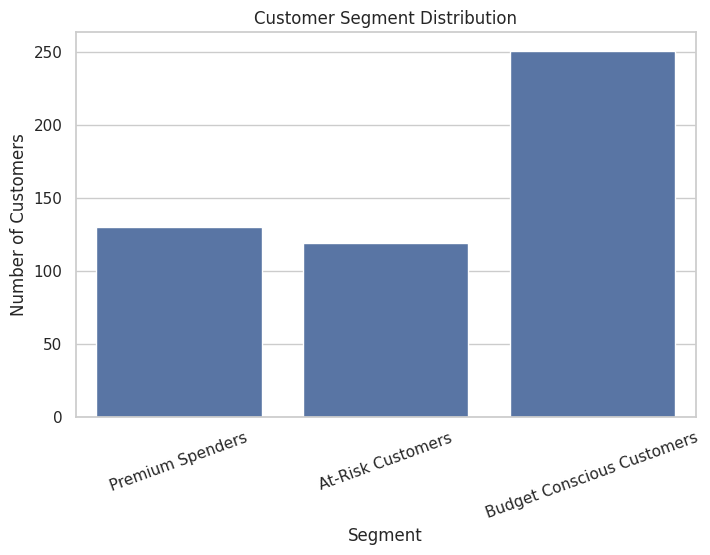

In [14]:
# Cell 14: Segment distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Segment_Name",
    data=encoded_df
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [15]:
# Cell 15: Build prediction models for each segment
results = []

feature_columns = encoded_df.drop(
    ["CustomerID", "Churn", "Segment_Name"],
    axis=1
).columns

for segment in encoded_df["KMeans_Segment"].unique():

    segment_data = encoded_df[encoded_df["KMeans_Segment"] == segment]

    X = segment_data[feature_columns]
    y = segment_data["Churn"]

    if y.nunique() < 2 or len(segment_data) < 20:
        print(f"Segment {segment} skipped due to insufficient class variation or small size")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Segment": segment,
        "Segment_Name": segment_names.get(segment, "Segment"),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

model_results = pd.DataFrame(results)

model_results

,Segment,Segment_Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,1,Premium Spenders,1.000000,1.0,1.0,1.0,1.0
1,2,At-Risk Customers,0.958333,0.0,0.0,0.0,1.0
2,0,Budget Conscious Customers,1.000000,1.0,1.0,1.0,1.0


In [16]:
# Cell 16: Hyperparameter tuning using GridSearchCV
X = encoded_df[feature_columns]
y = encoded_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [17]:
# Cell 17: Evaluate tuned model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("TUNED RANDOM FOREST MODEL PERFORMANCE")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

TUNED RANDOM FOREST MODEL PERFORMANCE
Accuracy : 0.96
Precision: 1.0
Recall   : 0.6363636363636364
F1 Score : 0.7777777777777778
ROC-AUC  : 0.9938712972420838

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        89
           1       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100



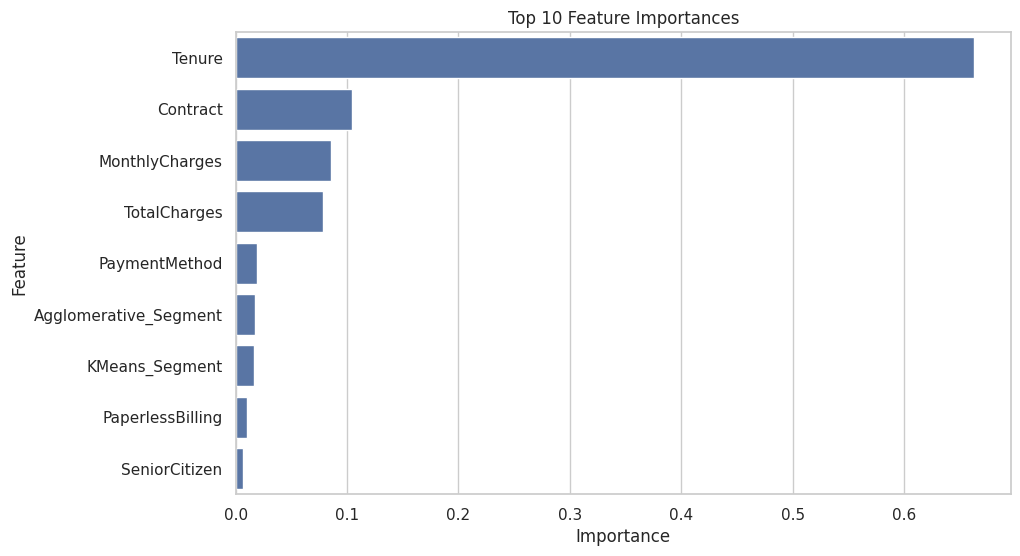

,Feature,Importance
0,Tenure,0.662731
3,Contract,0.104039
1,MonthlyCharges,0.085837
2,TotalCharges,0.078584
4,PaymentMethod,0.018832
8,Agglomerative_Segment,0.017537
7,KMeans_Segment,0.016282
5,PaperlessBilling,0.009891
6,SeniorCitizen,0.006267


In [18]:
# Cell 18: Feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Feature Importances")
plt.show()

feature_importance.head(10)

In [19]:
# Cell 19: Save model evaluation results
model_results.to_csv("model_evaluation_results.csv", index=False)

files.download("model_evaluation_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Cell 20: Final business recommendations
print("=" * 70)
print("CUSTOMER SEGMENTATION & PREDICTION REPORT")
print("=" * 70)

print("\nCustomer Segments:")
print("1. Budget Conscious Customers")
print("2. Premium Spenders")
print("3. At-Risk Customers")

print("\nBusiness Recommendations:")
print("1. Premium Spenders: Provide loyalty rewards and premium support.")
print("2. Budget Conscious Customers: Offer affordable plans and discounts.")
print("3. At-Risk Customers: Launch retention campaigns and personalized offers.")

print("\nModeling Summary:")
print("Random Forest was used for churn prediction.")
print("GridSearchCV was used for hyperparameter tuning.")
print("Accuracy, Precision, Recall, F1-score, and ROC-AUC were calculated.")

print("=" * 70)

CUSTOMER SEGMENTATION & PREDICTION REPORT

Customer Segments:
1. Budget Conscious Customers
2. Premium Spenders
3. At-Risk Customers

Business Recommendations:
1. Premium Spenders: Provide loyalty rewards and premium support.
2. Budget Conscious Customers: Offer affordable plans and discounts.
3. At-Risk Customers: Launch retention campaigns and personalized offers.

Modeling Summary:
Random Forest was used for churn prediction.
GridSearchCV was used for hyperparameter tuning.
Accuracy, Precision, Recall, F1-score, and ROC-AUC were calculated.
